## 美国核电产能与趋势分析

本研究以美国近年来核电产能以及使用趋势的研究数据为基础，对美国的核电产业进行数据化分析项目重点为
* 年度核电产值与使用的变化率
* 各地区的核电使用情况及其变化率
* 产业结构分析
* 总体产业分析

**一，获取数据**

In [38]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False
# 获取美国核电数据，通过获取其API调用数据

API_KEY = "4uHzt4DHXkT6q7VThHzMRMkE6oF7bCZlq1lnkjia"

url = "https://api.eia.gov/v2/electricity/electric-power-operational-data/data/"
params = {
    "api_key": API_KEY,
    "data[0]": "generation",
    "frequency": "annual",
    "facets[fueltypeid][]": "NUC",
    "sort[0][column]": "period",
    "sort[0][direction]": "desc",
    "length": 2000
}

response = requests.get(url, params=params)
data = response.json()
records = data['response']['data']

df = pd.DataFrame(records)
df = df[['period', 'location', 'stateDescription', 'sectorid', 'sectorDescription',
         'fueltypeid', 'fuelTypeDescription', 'generation', 'generation-units']]

df.to_csv('U202515697.csv', index=False, encoding='utf-8-sig')

**二，美国核电总体趋势分析**

1. 美国年度总产值基本情况以及最值分析

In [39]:
df = pd.read_csv('U202515697.csv')
df_US = df[(df['location'] == 'US') & (df['sectorid'] == 99)]
arr_US = np.array(df_US['generation'])

In [40]:
print(f"最近{len(arr_US)}年来美国核电全产业的总产值为{np.sum(arr_US)}千兆瓦时，"
      f"其中总产值最大的为{np.max(arr_US)}千兆瓦时，为{2025-np.argmax(arr_US)}年产值")

最近11年来美国核电全产业的总产值为8706895.03049千兆瓦时，其中总产值最大的为809409.262千兆瓦时，为2019年产值


2. 美国年度总产值趋势分析以及折线图绘制

In [41]:
x = []
y = []

for i in range(len(arr_US)):
    year = 2025 - (len(arr_US) - ( i + 1))
    x.append(year)
    y.append(arr_US[len(arr_US) - (i + 1)])

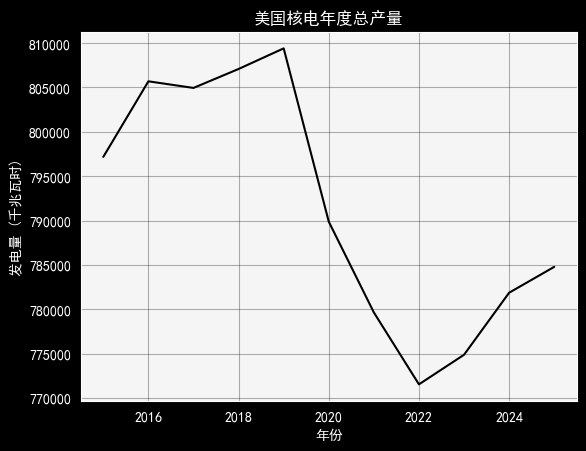

In [42]:
plt.plot(x, y, linestyle='-', color='black')
plt.gca().set_facecolor('#f5f5f5')
plt.title('美国核电年度总产量')
plt.xlabel('年份')
plt.ylabel('发电量 (千兆瓦时)')
plt.grid(True, alpha=0.3,color='black')
plt.show()

3. 年度同比增长率计算

In [43]:
growth_rate = []
values = np.array(df_US['generation'])

for i in range(1,len(arr_US)):
    rate = (values[i] - values[i-1])/values[i-1]*100
    growth_rate.append(rate)

years = np.array(x)
for i in range(0,len(years)-1):
    print(f"{years[i]}年的同比增长率为：{growth_rate[i]:.2f}%")


2015年的同比增长率为：-0.37%
2016年的同比增长率为：-0.89%
2017年的同比增长率为：-0.43%
2018年的同比增长率为：1.05%
2019年的同比增长率为：1.31%
2020年的同比增长率为：2.47%
2021年的同比增长率为：-0.29%
2022年的同比增长率为：-0.26%
2023年的同比增长率为：0.09%
2024年的同比增长率为：-1.06%


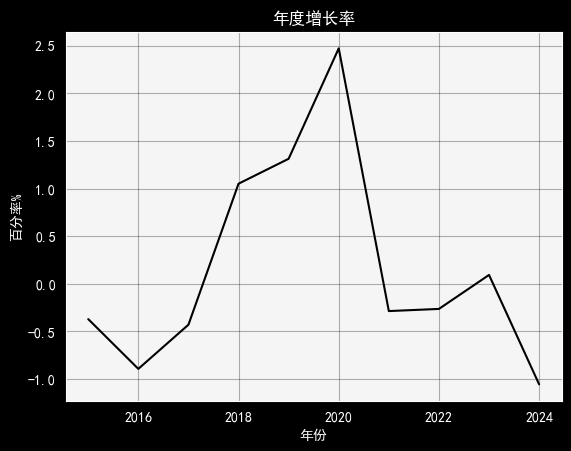

In [44]:
plt_years = years[:-1]
plt.plot(plt_years,growth_rate,linestyle='-', color='black')
plt.gca().set_facecolor('#f5f5f5')
plt.title('年度增长率')
plt.xlabel("年份")
plt.ylabel("百分率%")
plt.grid(True, alpha=0.3,color='black')
plt.show()

**二，各地区核电产能分析**

1. 各地区核电产能排位分析

In [45]:
'''
    AL 阿拉巴马州
    ENC 东北中部地区
    SAT 南大西洋地区
    90 太平洋地区
    ESC 东南中部地区
    MAT 中大西洋地区
    MTN 山区
    NEW 新英格兰地区
    WNC 西北中部地区
    WSC 西南中部地区
    PCC 太平洋沿岸地区
    US 美国全国总计
'''

df = pd.read_csv('U202515697.csv')


locations = ['AL', 'ENC', 'SAT', '90', 'ESC', 'MAT', 'MTN', 'NEW', 'WNC', 'WSC', 'PCC']

dfs = {loc: df[(df['location'] == loc) & (df['sectorid'] == 99)] for loc in locations}

# 计算各地区总和
arr_all_regions = np.array([np.sum(dfs[loc]['generation'].values) for loc in locations])

# 字典映射
dict_all_regions = {i: loc for i, loc in enumerate(locations)}

print(f"全部地区中近十年综合最高产量为{np.max(arr_all_regions):.2f},为{dict_all_regions[int(np.argmax(arr_all_regions))]}地区")

print(f"美国全国近十年核电总产量为{np.sum(arr_all_regions):.2f}千兆瓦时")

全部地区中近十年综合最高产量为2285602.88,为SAT地区
美国全国近十年核电总产量为9356097.14千兆瓦时


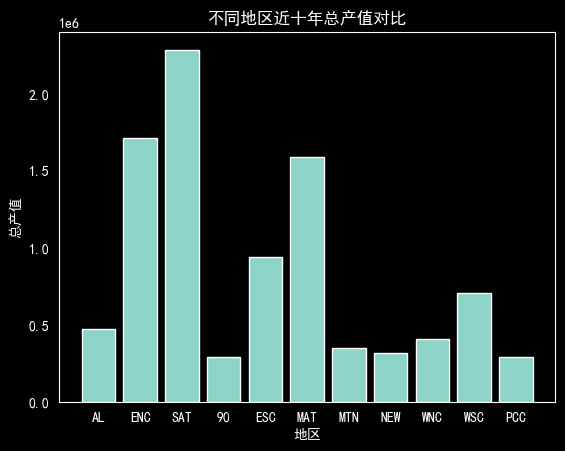

In [46]:
plt.bar(dict_all_regions.values(), arr_all_regions, align='center')
plt.title('不同地区近十年总产值对比')
plt.xlabel('地区')
plt.ylabel('总产值')
plt.grid(True, alpha=0.3,color='black')
plt.show()

2. 地区所占全国市场份额分析

In [47]:
# 定义计算市场份额的函数 方便后续调用以及数据分析
dict_states_generation = dict(zip(dict_all_regions.values(),arr_all_regions))

def sum_generation(arr):
    return np.sum(arr)

def market_shares(generation, total):
    return generation / total * 100

# 占全美的比例
print("\n各地区占全美总量的市场份额：")
for key, value in dict_states_generation.items():
    share_national = market_shares(value,sum_generation(arr_all_regions) )
    print(f"{key}地区近十年时间内生产总额占全美总量的比例为{share_national:.2f}%")


各地区占全美总量的市场份额：
AL地区近十年时间内生产总额占全美总量的比例为5.05%
ENC地区近十年时间内生产总额占全美总量的比例为18.28%
SAT地区近十年时间内生产总额占全美总量的比例为24.43%
90地区近十年时间内生产总额占全美总量的比例为3.12%
ESC地区近十年时间内生产总额占全美总量的比例为10.06%
MAT地区近十年时间内生产总额占全美总量的比例为16.95%
MTN地区近十年时间内生产总额占全美总量的比例为3.75%
NEW地区近十年时间内生产总额占全美总量的比例为3.36%
WNC地区近十年时间内生产总额占全美总量的比例为4.35%
WSC地区近十年时间内生产总额占全美总量的比例为7.52%
PCC地区近十年时间内生产总额占全美总量的比例为3.12%


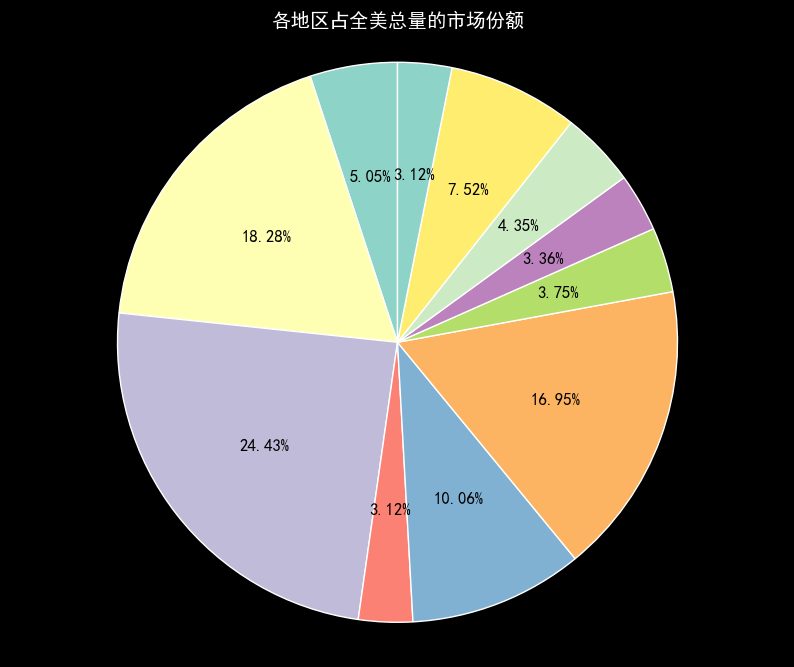

In [48]:
plt.figure(figsize=(10, 8))
plt.pie(arr_all_regions, labels=dict_all_regions.values(), autopct='%1.2f%%', startangle=90,textprops={'color': 'black', 'fontsize': 12})
plt.title('各地区占全美总量的市场份额', fontsize=14, fontweight='bold')
plt.axis('equal')
plt.show()

**三，产业结构与产值分析**

1. 产业结构统计以及逐年各产业产值分析

In [49]:
'''
    99: 全行业统计
    1: 电力公司
    2: 独立发电商
    98: 电力行业总计
'''
df = pd.read_csv('U202515697.csv')


df_2025_1 = df[(df['sectorid'] == 1) & (df['period'] == 2025) & (df['stateDescription'] != 'U.S. Total')]
df_2025_2 = df[(df['sectorid'] == 2) & (df['period'] == 2025) & (df['stateDescription'] != 'U.S. Total')]
df_2025_98 = df[(df['sectorid'] == 98) & (df['period'] == 2025) & (df['stateDescription'] != 'U.S. Total')]

total_1 = np.sum(df_2025_1['generation'].values)
total_2 = np.sum(df_2025_2['generation'].values)
total_98 = np.sum(df_2025_98['generation'].values)

print(f"电力公司(1)总产值: {total_1:.2f} 千兆瓦时")
print(f"独立发电商(2)总产值: {total_2:.2f} 千兆瓦时")
print(f"电力行业总计(98)总产值: {total_98:.2f} 千兆瓦时")

电力公司(1)总产值: 914052.25 千兆瓦时
独立发电商(2)总产值: 680815.70 千兆瓦时
电力行业非CHP(90)总产值: 1594867.94 千兆瓦时
电力行业总计(98)总产值: 1594867.94 千兆瓦时


2. 产业洛伦兹曲线

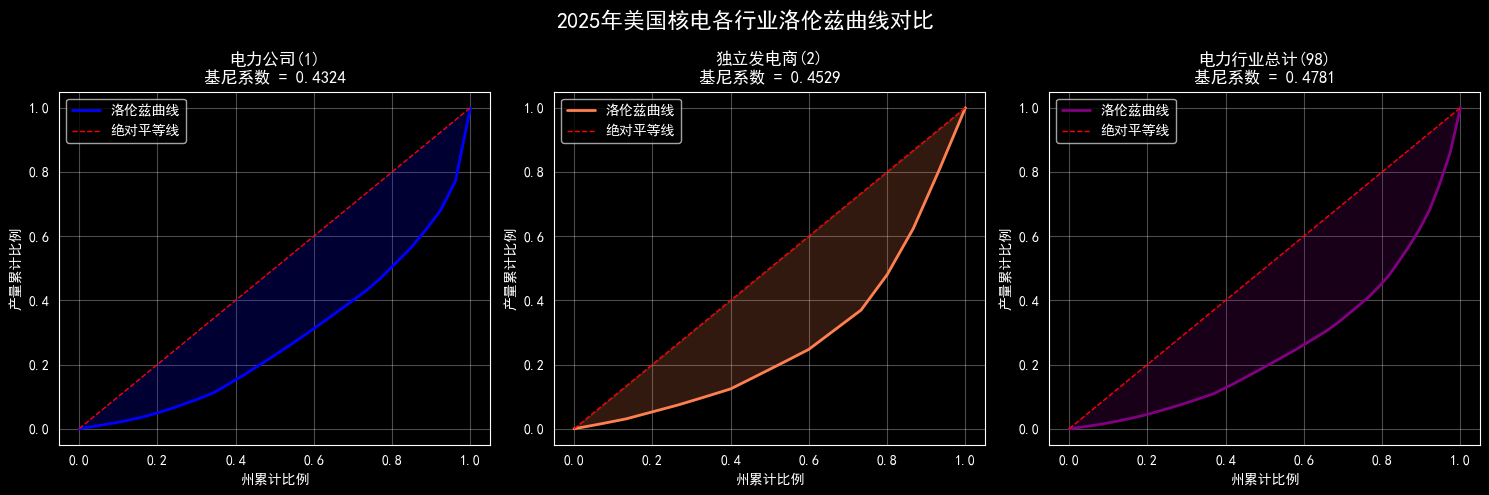

In [56]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

def plot_lorenz_curve_subplot(values, title, ax, color):
    values_sorted = np.sort(values)
    cumulative = np.cumsum(values_sorted) / np.sum(values_sorted)
    cumulative = np.insert(cumulative, 0, 0)
    x = np.linspace(0, 1, len(cumulative))

    n = len(values_sorted)
    gini = 1 - 2 * np.sum(cumulative[1:]) / n + 1 / n

    ax.plot(x, cumulative, color=color, linewidth=2, label='洛伦兹曲线')
    ax.plot([0, 1], [0, 1], 'r--', linewidth=1, label='绝对平等线')
    ax.fill_between(x, cumulative, x, alpha=0.2, color=color)
    ax.set_title(f'{title}\n基尼系数 = {gini:.4f}', fontsize=12)
    ax.set_xlabel('州累计比例')
    ax.set_ylabel('产量累计比例')
    ax.legend()
    ax.grid(True, alpha=0.3)
    return gini

# 各行业数据
values_1 = df_2025_1.groupby('stateDescription')['generation'].sum().values
values_1 = values_1[values_1 > 0]
values_2 = df_2025_2.groupby('stateDescription')['generation'].sum().values
values_2 = values_2[values_2 > 0]
values_98 = df_2025_98.groupby('stateDescription')['generation'].sum().values
values_98 = values_98[values_98 > 0]

gini_1 = plot_lorenz_curve_subplot(values_1, '电力公司(1)', axes[0], 'blue')
gini_2 = plot_lorenz_curve_subplot(values_2, '独立发电商(2)', axes[1], 'coral')
gini_98 = plot_lorenz_curve_subplot(values_98, '电力行业总计(98)', axes[2], 'purple')

plt.suptitle('2025年美国核电各行业洛伦兹曲线对比', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

3. 赫芬达尔指数计算

In [58]:
def calculate_hhi(values):
    if len(values) == 0:
        return 0, "无数据"
    total = np.sum(values)
    shares = (values / total) * 100
    hhi = np.sum(shares ** 2)
    if hhi < 1500:
        market_type = "竞争市场"
    elif hhi < 2500:
        market_type = "中度集中市场"
    else:
        market_type = "高度集中市场"
    return hhi, market_type

share_1 = (total_1 / total_98) * 100
share_2 = (total_2 / total_98) * 100
hhi_value, market_type = calculate_hhi(np.array([total_1, total_2]))

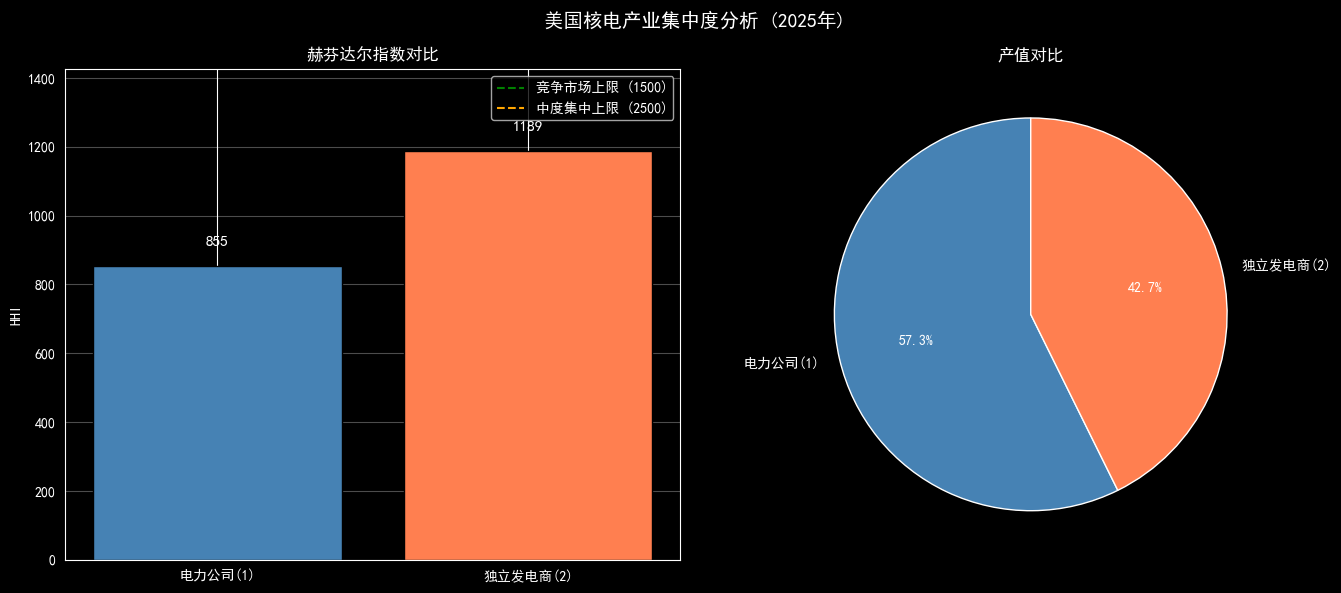

In [63]:
labels = ['电力公司', '独立发电商']
sizes = [share_1, share_2]
colors = ['#66b3ff', '#ff9999']

plt.figure(figsize=(8, 8))
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.2f%%', startangle=90)
plt.title(f'美国核电产业结构 (2025年)\nHHI = {hhi_value:.2f} ({market_type})', fontsize=12)
plt.axis('equal')
plt.show()